Load required Python libraries

In [13]:
import os
from langchain_chroma import Chroma
from chromadb.config import Settings as ChromaSettings
from langchain_community import embeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chains.question_answering import load_qa_chain
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from chromadb import PersistentClient
import time
import pandas as pd
import re
from lxml import etree
from tqdm import tqdm
import hashlib
import math

Load ollama embeddings 

In [14]:
from langchain_community.embeddings import HuggingFaceEmbeddings
# oder: from langchain_huggingface import HuggingFaceEmbeddings

EMBEDDINGS = HuggingFaceEmbeddings(
    model_name="jinaai/jina-embeddings-v3",
    model_kwargs={"trust_remote_code": True},
    encode_kwargs={"normalize_embeddings": True},  # praktisch für Cosine
)

PERSIST_DIR = "./chroma_langchain"

In [15]:
MAX_CHARS = 3000  # konservativ; bei Bedarf 6000–8000

def _clamp_chunks(chunks, max_chars=MAX_CHARS):
    # schneidet nur zu lange Chunks hart ab (keine großen Refactors nötig)
    return [c if len(c) <= max_chars else c[:max_chars] for c in chunks]

In [16]:
def _stable_id(text: str) -> str:
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

# EIN Persistent Client für die ganze Session
_client = PersistentClient(path=PERSIST_DIR)

def load_vector_store():
    return Chroma(
        client=_client,                        # <— wichtig
        embedding_function=EMBEDDINGS,
    )

def create_or_update_vector_store(chunks, batch_size: int = 64):
    chunks = _clamp_chunks(chunks)  # <<< NEU: verhindert den 3GB-Alloc sofort
    vdb = load_vector_store()

    # Existierende IDs einsammeln (nur IDs, keine Embeddings laden)
    try:
        existing_ids = set(vdb.get(include=[]).get("ids", []))
    except Exception:
        existing_ids = set()

    texts, metas, ids = [], [], []
    seen = set()
    for ch in chunks:
        h = _stable_id(ch)
        if h in existing_ids or h in seen:
            continue
        seen.add(h)
        texts.append(ch)
        metas.append({})
        ids.append(h)

    if not ids:
        print("✅ Keine neuen Chunks.")
        return vdb

    num_batches = math.ceil(len(ids) / batch_size)
    print(f"📥 Neue Chunks: {len(ids)} → {num_batches} Batches")

    for b in tqdm(range(num_batches), desc="🔧 Indexing", unit="batch"):
        s, e = b * batch_size, min((b + 1) * batch_size, len(ids))
        vdb.add_texts(texts=texts[s:e], metadatas=metas[s:e], ids=ids[s:e])

    print("✅ Fertig. (Persistenz erfolgt automatisch über PersistentClient)")
    return vdb

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


In [17]:
parser = etree.XMLParser(huge_tree=True, recover=True)
tree = etree.parse("leitsatzDB_all.xml", parser)

rows = []
for row in tree.findall(".//row"):
    rec = {}
    for child in row:
        rec[child.tag] = (child.text or "").strip()
    rows.append(rec)

df = pd.DataFrame(rows)
print(df.head())
print(len(df))

    aktenzeichen                                           leitsatz
0  XIII ZB 65/23  AufenthG § 62 Abs. 3b Nr. 2\nWelches Gewicht d...
1    I ZR 122/23  BGB § 655a Abs. 1 Satz 1 Nr. 1, Abs. 3, § 511\...
2  XII ZB 477/22  BGB §§ 1821 Abs. 1 Nr. 1, 1835 Abs. 3 aF; FamF...
3     I ZB 48/24  ZPO § 1031 Abs. 6, § 1032 Abs. 2\na) Die (vorb...
4     I ZB 39/24  ZPO § 148 Abs. 1, § 252; AEUV Art. 267\nGegen ...
21613


Load data and create chunks

In [18]:
chunks = []

for _, row in df.iterrows():
    # Headnote, otherwise Catchword
    text = row["leitsatz"] 
    
    # if Catchword is NaN → skip
    if pd.isna(text):
        continue
    
    # format string
    entry = f'{row["aktenzeichen"]}: {text}'
    chunks.append(entry)

file_path = "chunks.txt"

# write all chunks in one TXT
with open(file_path, "w", encoding="utf-8") as f:
    for chunk in chunks:
        f.write(chunk + "\n")

print(f"{len(chunks)} Chunks saved in {file_path}.")


21613 Chunks saved in chunks.txt.


Create vector store (did not work at first run, excecute twice)

In [19]:
# Create vector store
vector_store = create_or_update_vector_store(chunks)

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


📥 Neue Chunks: 15201 → 238 Batches


🔧 Indexing: 100%|██████████████████████████████████████████████████████████████| 238/238 [4:36:58<00:00, 69.82s/batch]

✅ Fertig. (Persistenz erfolgt automatisch über PersistentClient)


In [11]:
vs = load_vector_store()

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [12]:
data = vs._collection.get(
    include=["metadatas", "documents"],  # KEIN "ids" hier!
)
#print(data["ids"])         # <- ist trotzdem da
#print(data["metadatas"])
#print(data["documents"])
len(data["documents"])

21603

In [17]:
docs = vs.similarity_search("Gesellschafter", k=3)
print(docs[0].metadata)   # zeigt z. B. {'source': 'G1/15', ...}
print(docs[0].page_content)

{}
II ZR 275/14: GmbHG § 47
Aufgrund der Treuepflicht muss der Gesellschafter einer Maßnahme zustimmen,
wenn sie zur Erhaltung wesentlicher Werte, die die Gesellschafter geschaffen haben,
oder zur Vermeidung erheblicher Verluste, die die Gesellschaft bzw. die Gesellschafter erleiden könnten, objektiv unabweisbar erforderlich ist und den Gesellschaftern
unter Berücksichtigung ihrer eigenen schutzwürdigen Belange zumutbar ist, also
wenn der Gesellschaftszweck und das Interesse der Gesellschaft gerade diese Maßnahme zwingend gebieten und der Gesellschafter seine Zustimmung ohne vertretbaren Grund verweigert.


----------------------


# Visualization of the vector store

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


87


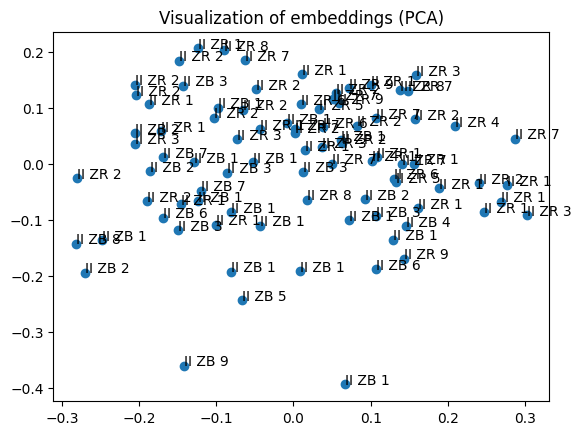

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

vector_store_loaded = load_vector_store()

# load vectore
data = vector_store_loaded.get(include=["embeddings", "documents"])
embeddings = data["embeddings"]
docs = data["documents"]

# 2D reduction via PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# plotting
#plt.figure(figsize=(10, 7))
plt.scatter(reduced[:, 0], reduced[:, 1])

print(len(docs))
# Optional: Dokumentausschnitte als Labels anzeigen
for i, txt in enumerate(docs):
#for i, txt in enumerate(docs[:50]):  # not too many at once
    plt.annotate(txt[:7], (reduced[i, 0], reduced[i, 1]))  # Kür

plt.title("Visualization of embeddings (PCA)")
plt.savefig("embedding_plot.png", dpi=300, bbox_inches='tight') 

plt.show()


In [10]:
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"  # ideal für JupyterLab 3+
# Alternativen, falls nötig: "notebook_connected" oder "iframe"

Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


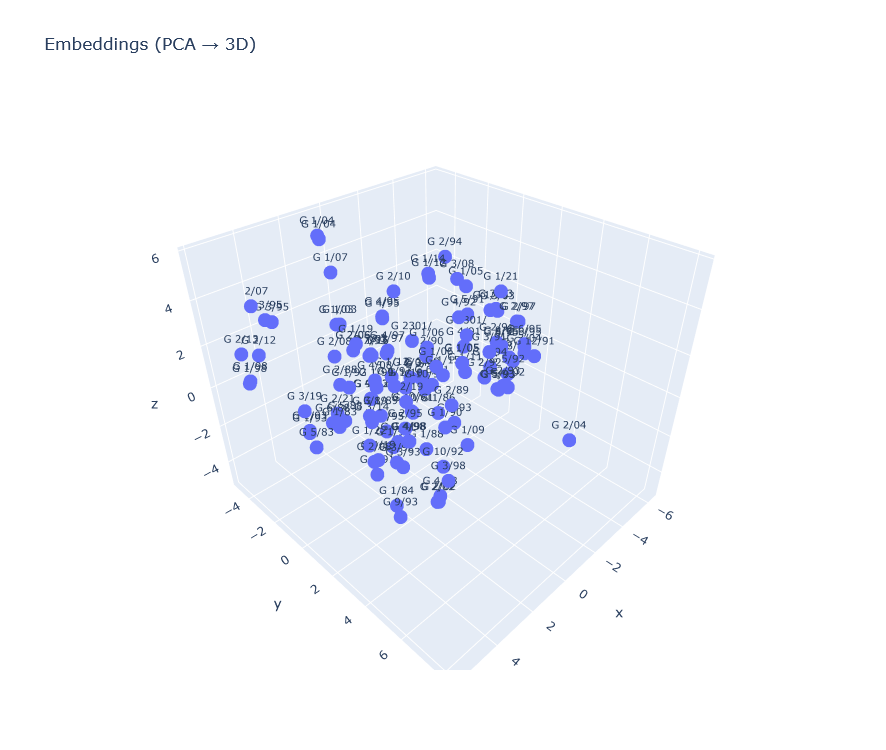

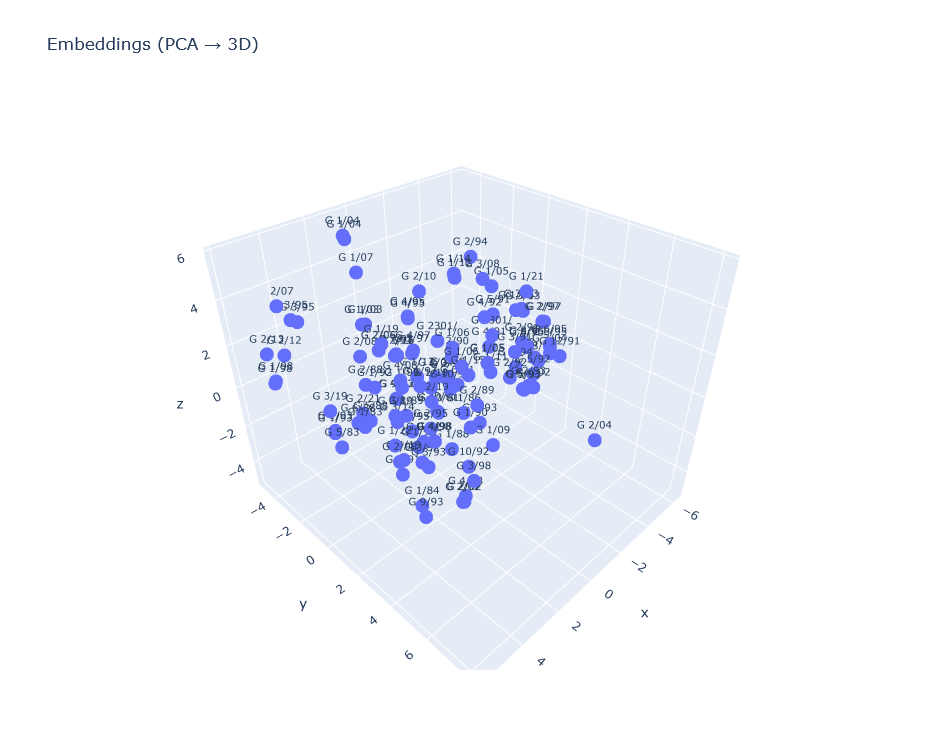

Punkte: 240 Embeddings-Shape: (240, 768)


In [11]:
import numpy as np, pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px, plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display

pio.renderers.default = "plotly_mimetype"   # oder "notebook_connected"

vs = vector_store_loaded

# Daten holen (ohne 'ids' in include!)
n = vs._collection.count()
data = vs._collection.get(include=["embeddings","documents","metadatas"], limit=n)

embeddings = np.asarray(data["embeddings"], dtype=float)
ids   = data.get("ids") or [str(i) for i in range(len(embeddings))]
docs  = data.get("documents") or [""] * len(embeddings)
metas = data.get("metadatas") or [{}] * len(embeddings)

# Robustheit
mask = np.isfinite(embeddings).all(axis=1)
embeddings = embeddings[mask]
ids   = [i for i, m in zip(ids, mask) if m]
docs  = [d for d, m in zip(docs, mask) if m]
metas = [m for m, msk in zip(metas, mask) if msk]

# PCA → 3D
pca = PCA(n_components=3, random_state=42)
reduced = pca.fit_transform(embeddings)

df = pd.DataFrame(metas)
df.insert(0, "id", ids)
# Volltext-Snippet (für Hover)
df["text"] = [(d or "").replace("\n"," ")[:200] for d in docs]
# NEU: Label (erste 7 Zeichen der Docs, bereinigt)
df["label7"] = [((d or "").replace("\n"," ").strip())[:7] or "…" for d in docs]

df["x"], df["y"], df["z"] = reduced[:,0], reduced[:,1], reduced[:,2]

color_by = "source" if "source" in df.columns else None

fig = px.scatter_3d(
    df, x="x", y="y", z="z",
    color=color_by,
    hover_data=["id","text"] + ([color_by] if color_by else []),
    height=750,
    title="Embeddings (PCA → 3D)"
)

# Labels nur für wenige Punkte (z. B. die ersten 40)
#label_n = min(40, len(df))
lab = df
fig.add_trace(go.Scatter3d(
    x=lab["x"], y=lab["y"], z=lab["z"],
    mode="text",                 # "markers+text" für Punkte + Text
    text=lab["label7"],          # <- hier kommen die 7-Zeichen-Labels hin
    showlegend=False,
    textfont=dict(size=10)
))

# Anzeige erzwingen
display(fig)
fig.show()

# Fallback: als HTML speichern (öffnet Browser)
fig.write_html("embedding_plot_3d.html", include_plotlyjs="inline", auto_open=True)

print("Punkte:", len(df), "Embeddings-Shape:", embeddings.shape)


In [19]:
import os
os.environ["CHROMA_TELEMETRY_DISABLED"] = "1"

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain.schema import Document
from chromadb.config import Settings

PERSIST_DIR = "./chroma_langchain"

emb = HuggingFaceEmbeddings(
    model_name="nomic-ai/nomic-embed-text-v1.5",
    model_kwargs={"trust_remote_code": True},
    encode_kwargs={"normalize_embeddings": True},
)


docs = [
    Document(page_content="Double patenting in Europe is addressed in G 4/19 (headnote).",
             metadata={"source":"G4/19"}),
    Document(page_content="Priority entitlement in partial priority context is discussed in G 1/15.",
             metadata={"source":"G1/15"}),
    Document(page_content="Questions on clarity in opposition proceedings are covered in G 3/14.",
             metadata={"source":"G3/14"}),
]

vs = Chroma.from_documents(
    documents=docs,
    embedding=emb,
    persist_directory=PERSIST_DIR,

)

print("OK: test index created in", PERSIST_DIR)


<All keys matched successfully>
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


AttributeError: 'Chroma' object has no attribute 'persist'